# Distorted Visual Sequence Recognition — CRNN Approach

## Problem
Given 20,000 grayscale images of distorted 6-character alphanumeric sequences,
build a model that predicts the correct character sequence despite:
- Heavy black blob occlusion covering parts of characters
- Background noise and visual artifacts
- Irregular character spacing and alignment
- Shape deformation and blur

**Evaluation metric:** Character Error Rate (CER) — lower is better.
**Dataset:** 20,000 training images, 5,000 test images, 38-character vocabulary.

## Why CRNN?

This is a sequence recognition problem, not a classification problem.
A plain CNN would treat each character independently — but characters
in a sequence have spatial relationships that matter.

**The architecture:**
- **CNN (5 conv blocks):** Extracts visual features column by column.
  Each block uses Conv2d → BatchNorm → ReLU → MaxPool.
  The image (1×32×128) is progressively compressed to (256×1×32),
  producing 32 feature columns — one per time step.
  
- **BiLSTM (2 layers, 256 hidden units):** Reads the 32 feature columns
  left-to-right AND right-to-left simultaneously. Bidirectional matters
  here because the model can use context from both sides to resolve
  ambiguous characters — especially under occlusion.

- **CTC Loss:** Connectionist Temporal Classification. Unlike cross-entropy,
  CTC doesn't require character-level alignment between input and output.
  It learns to align automatically, which is essential when character
  positions vary due to distortion.

**Why not a plain classifier?**
Fixed-length (6 chars) means we could use 6 independent classifiers.
But CTC + BiLSTM captures sequential dependencies — if the model sees
partial evidence of 'Q' followed by context suggesting a round character,
it can resolve the ambiguity better than an isolated classifier.

## Training Observations

Training ran for 30 epochs on a T4 GPU (Google Colab).

**Key observation: plateau then breakthrough**

Epochs 1–18: Loss plateaued around 3.56, CER stayed near 1.0.
The model was stuck — CTC loss requires the model to simultaneously
learn feature extraction AND sequence alignment, which creates a
difficult optimization landscape early in training.

Epoch 19: Sudden breakthrough — loss dropped from 3.53 to 3.14,
CER fell from 0.96 to 0.87. The model found a viable alignment strategy.

Epochs 20–30: Rapid improvement. Loss dropped to 0.05, CER to 0.0249.

**Final results:**
- Train Loss: 0.0512
- Val Loss: 0.1085  
- Val CER: 0.0249 (97.5% character accuracy)
- Sequence accuracy: 85.85% (1,717 / 2,000 perfectly predicted)

The gap between train and val loss suggests mild overfitting —
a longer training run with stronger dropout or data augmentation
could close this gap further.

## Error Analysis

Out of 2,000 validation sequences, 283 contained at least one character error.

**Top confused character pairs:**

| True | Predicted As | Count | Reason |
|------|-------------|-------|--------|
| C | G | 17 | Both are open round characters — the blob occludes the opening of C, making it look closed like G |
| 6 | 8 | 17 | Both have closed loops — upper portion of 6 resembles 8 under noise |
| F | P | 11 | Both have vertical stroke + horizontal bars — lower bar of F occluded |
| 5 | 8 | 11 | Similar curve structure in upper half |
| Z | 2 | 9 | Similar diagonal stroke pattern |
| 3 | 9 | 8 | Upper curve similar, lower portion occluded |

**Key insight:** The model's errors are not random — they are visually
motivated confusions. Every top confused pair shares a geometric similarity
that becomes ambiguous under the specific distortions in this dataset
(blob occlusion, noise). This suggests the CNN features are meaningful
— the model is genuinely reading the images, not guessing.

**What would fix this:**
1. Data augmentation targeted at these pairs during training
2. A larger CNN backbone (e.g. ResNet18) for richer feature extraction
3. Attention mechanism to focus on unoccluded regions of each character

## Future Improvements

1. **Preprocessing:** Adaptive thresholding to separate text from the
   black blob before feeding to CNN — hypothesized to improve C/G and 6/8
   confusion significantly.

2. **Stronger backbone:** Replace custom CNN with pretrained ResNet18
   — transfer learning from ImageNet gives richer low-level features.

3. **Attention mechanism:** Add attention on top of BiLSTM output to
   let the model focus on the most discriminative time steps per character.

4. **Data augmentation:** Synthetic augmentation targeting the specific
   distortion types — random ellipse occlusion, gaussian noise — to make
   the model more robust.

5. **Beam search decoding:** Replace greedy CTC decode with beam search
   for better sequence-level predictions.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

!pip install textdistance -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
from pathlib import Path

TRAIN_IMG_DIR = Path("/content/drive/MyDrive/train_images")
TRAIN_CSV     = Path("/content/drive/MyDrive/train-labels.csv")
TEST_IMG_DIR  = Path("/content/drive/MyDrive/test_images")

import os
print(os.path.exists(TRAIN_IMG_DIR))  # must print True
print(os.path.exists(TRAIN_CSV))      # must print True
print(os.path.exists(TEST_IMG_DIR))   # must print True

True
True
True


In [7]:
import shutil, os

LOCAL_TRAIN = Path("/content/train_images")
LOCAL_TRAIN.mkdir(exist_ok=True)

files = list(TRAIN_IMG_DIR.glob("*"))
for i, f in enumerate(files):
    shutil.copy(f, LOCAL_TRAIN / f.name)
    if i % 1000 == 0:
        print(f"{i}/{len(files)} copied...")

LOCAL_TEST = Path("/content/test_images")
LOCAL_TEST.mkdir(exist_ok=True)

files = list(TEST_IMG_DIR.glob("*"))
for i, f in enumerate(files):
    shutil.copy(f, LOCAL_TEST / f.name)
    if i % 1000 == 0:
        print(f"{i}/{len(files)} copied...")

TRAIN_IMG_DIR = LOCAL_TRAIN
TEST_IMG_DIR  = LOCAL_TEST

0/20012 copied...
1000/20012 copied...
2000/20012 copied...
3000/20012 copied...
4000/20012 copied...
5000/20012 copied...
6000/20012 copied...
7000/20012 copied...
8000/20012 copied...
9000/20012 copied...
10000/20012 copied...
11000/20012 copied...
12000/20012 copied...
13000/20012 copied...
14000/20012 copied...
15000/20012 copied...
16000/20012 copied...
17000/20012 copied...
18000/20012 copied...
19000/20012 copied...
20000/20012 copied...
0/5010 copied...
1000/5010 copied...
2000/5010 copied...
3000/5010 copied...
4000/5010 copied...
5000/5010 copied...


In [25]:
# Delete all the (1) duplicate files
test_files = list(Path(TEST_IMG_DIR).glob("*.png"))
duplicates_to_remove = [f for f in test_files if '(1)' in f.name]

print(f"Files to remove: {len(duplicates_to_remove)}")
for f in duplicates_to_remove:
    print(f"  Deleting: {f.name}")
    os.remove(f)

# Verify
remaining = list(Path(TRAIN_IMG_DIR).glob("*.png"))
print(f"\nRemaining files: {len(remaining)}")
train_files = list(Path(TRAIN_IMG_DIR).glob("*.png"))
duplicates_to_remove = [f for f in train_files if '(1)' in f.name]

print(f"Files to remove: {len(duplicates_to_remove)}")
for f in duplicates_to_remove:
    print(f"  Deleting: {f.name}")
    os.remove(f)

# Verify
remaining = list(Path(TRAIN_IMG_DIR).glob("*.png"))
print(f"\nRemaining files: {len(remaining)}")

Files to remove: 10
  Deleting: test-1123 (1).png
  Deleting: test-1168 (1).png
  Deleting: test-1126 (1).png
  Deleting: test-1125 (1).png
  Deleting: test-1167 (1).png
  Deleting: test-1172 (1).png
  Deleting: test-1121 (1).png
  Deleting: test-117 (1).png
  Deleting: test-1166 (1).png
  Deleting: test-1169 (1).png

Remaining files: 20012
Files to remove: 12
  Deleting: train-3813 (1).png
  Deleting: train-3811 (1).png
  Deleting: train-3766 (1).png
  Deleting: train-3817 (1).png
  Deleting: train-3762 (1).png
  Deleting: train-3810 (1).png
  Deleting: train-3809 (1).png
  Deleting: train-3761 (1).png
  Deleting: train-3763 (1).png
  Deleting: train-3765 (1).png
  Deleting: train-376 (1).png
  Deleting: train-3818 (1).png

Remaining files: 20000


In [26]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as tranforms
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import textdistance
from sklearn.model_selection import train_test_split

# ─── TO DEFINE THE GPU DEVICE ───
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [27]:
CHARS = ['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7',
         '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J',
         'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W',
         'X', 'Y', 'Z', 'a', 'r']

BLANK = '-ctc-'
VOCAB = [BLANK] + CHARS
char2idx = {c: i for i, c in enumerate(VOCAB)}
idx2char = {i: c for c, i in char2idx.items()}

NUM_CLASSES = len(VOCAB)  # 39
SEQ_LEN = 6

print(f"Vocabulary size: {NUM_CLASSES}")

Vocabulary size: 39


In [28]:
test_files = list(Path(TEST_IMG_DIR).glob("*.png"))
print(f"Total test images: {len(test_files)}")

# Check for duplicates
names = [f.name for f in test_files]
print(f"Unique names: {len(set(names))}")

Total test images: 5000
Unique names: 5000


In [29]:
#Pre-load datasets into RAM
class CaptchaDataset(Dataset):
    def __init__(self, df, img_dir):
        self.img_dir = Path(img_dir)
        original_len = len(df)
        self.df = df[df['text'].apply(lambda x: len(str(x)) == 6)].reset_index(drop=True)
        print(f"Dataset: {len(self.df)} valid samples ({original_len - len(self.df)} removed)")

        # Preload all images into RAM (CAPTCHAs are tiny, ~few hundred MB max)
        print("Preloading images into RAM...")
        self.images = []
        for idx in range(len(self.df)):
            img_name = self.df.iloc[idx]['image']
            img = cv2.imread(str(self.img_dir / img_name), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (128, 32))
            img = np.expand_dims(img, axis=0).astype(np.float32) / 255.0
            self.images.append(torch.tensor(img))
        print("Done preloading.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        label_str = str(self.df.iloc[idx]['text'])
        label_encoded = torch.tensor([char2idx[c] for c in label_str], dtype=torch.long)
        return self.images[idx], label_encoded, label_str



In [30]:
df = pd.read_csv(TRAIN_CSV)
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)

train_dataset = CaptchaDataset(train_df, TRAIN_IMG_DIR)
val_dataset   = CaptchaDataset(val_df,   TRAIN_IMG_DIR)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

imgs, labels, label_strs = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}")
print(f"Sample: {label_strs[0]}")

Dataset: 17998 valid samples (2 removed)
Preloading images into RAM...
Done preloading.
Dataset: 2000 valid samples (0 removed)
Preloading images into RAM...
Done preloading.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batch shape: torch.Size([64, 1, 32, 128])
Sample: 2DAA9D


In [31]:
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super(CRNN, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d((2,1), (2,1)),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d((2,1), (2,1)),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d((2,1), (2,1)),
        )

        self.rnn = nn.LSTM(256, 256, num_layers=2,
                           batch_first=True,
                           bidirectional=True,
                           dropout=0.3)

        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        features = self.cnn(x)
        b, c, h, w = features.size()
        features = features.squeeze(2)
        features = features.permute(0, 2, 1)
        output, _ = self.rnn(features)
        output = self.fc(output)
        output = output.permute(1, 0, 2)
        return output

model = CRNN(num_classes=NUM_CLASSES)
model = model.to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 3,629,031


In [32]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CTCLoss(blank=0, reduction='mean')
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

def encode_labels(label_strs):
    targets, target_lengths = [], []
    for s in label_strs:
        encoded = [char2idx[c] for c in s]
        targets.extend(encoded)
        target_lengths.append(len(s))
    return torch.tensor(targets, dtype=torch.long), \
           torch.tensor(target_lengths, dtype=torch.long)

def decode_predictions(outputs):
    _, max_indices = outputs.max(2)
    max_indices = max_indices.permute(1, 0).cpu().numpy()
    decoded = []
    for sequence in max_indices:
        chars = []
        prev = None
        for idx in sequence:
            if idx != prev and idx != 0:
                chars.append(idx2char[idx])
            prev = idx
        decoded.append("".join(chars))
    return decoded

def compute_cer(predictions, targets):
    total_dist = sum(textdistance.levenshtein(p, t) for p, t in zip(predictions, targets))
    total_len  = sum(len(t) for t in targets)
    return total_dist / total_len if total_len > 0 else 0

In [ ]:
scaler = torch.amp.GradScaler('cuda')

def train_one_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for images, labels, label_strs in train_loader:
        images = images.to(device, non_blocking=True)
        targets, target_lengths = encode_labels(label_strs)
        targets = targets.to(device, non_blocking=True)
        target_lengths = target_lengths.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):  # ← mixed precision
            outputs = model(images)
            log_probs = outputs.log_softmax(2)
            input_lengths = torch.full((images.size(0),), outputs.size(0),
                                       dtype=torch.long, device=device)
            loss = criterion(log_probs, targets, input_lengths, target_lengths)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    return running_loss / len(train_loader)


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for imgs, labels, label_strs in loader:
            imgs = imgs.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():  # ← mixed precision here too
                outputs = model(imgs)
                targets, target_lengths = encode_labels(label_strs)
                targets = targets.to(device, non_blocking=True)
                target_lengths = target_lengths.to(device, non_blocking=True)
                input_lengths = torch.full((imgs.size(0),), outputs.size(0),
                                           dtype=torch.long, device=device)
                log_probs = outputs.log_softmax(2)
                loss = criterion(log_probs, targets, input_lengths, target_lengths)

            total_loss += loss.item()
            all_preds.extend(decode_predictions(outputs))
            all_targets.extend(label_strs)

    cer = compute_cer(all_preds, all_targets)
    return total_loss / len(loader), cer, all_preds[:5], all_targets[:5]

/tmp/ipykernel_8008/840563124.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [15]:
NUM_EPOCHS = 30
best_cer = float('inf')
history = {"train_loss": [], "val_loss": [], "val_cer": []}

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_cer, sample_preds, sample_targets = validate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_cer"].append(val_cer)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val CER: {val_cer:.4f}")
    print(f"Predictions: {sample_preds}")
    print(f"Targets:     {sample_targets}")

    if val_cer < best_cer:
        best_cer = val_cer
        torch.save(model.state_dict(), "/content/drive/MyDrive/best_model.pth")
        print(f"  ✓ Saved best model (CER: {best_cer:.4f})")


Epoch 1/30
----------------------------------------


/tmp/ipykernel_8008/840563124.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # ← mixed precision
/tmp/ipykernel_8008/840563124.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # ← mixed precision here too


Train Loss: 3.9204 | Val Loss: 3.6541 | Val CER: 1.0000
Predictions: ['', '', '', '', '']
Targets:     ['48TADN', '9JEGA6', '3JY9FC', 'GXNHGU', 'B4238J']
  ✓ Saved best model (CER: 1.0000)

Epoch 2/30
----------------------------------------
Train Loss: 3.5864 | Val Loss: 3.5764 | Val CER: 0.9647
Predictions: ['5J77Q7', '5J77Q7', '5J77Q7', '5J77Q7', '5J77Q7']
Targets:     ['48TADN', '9JEGA6', '3JY9FC', 'GXNHGU', 'B4238J']
  ✓ Saved best model (CER: 0.9647)

Epoch 3/30
----------------------------------------
Train Loss: 3.5725 | Val Loss: 3.5720 | Val CER: 0.9663
Predictions: ['8888', '8888', '8888', '8888', '8888']
Targets:     ['48TADN', '9JEGA6', '3JY9FC', 'GXNHGU', 'B4238J']

Epoch 4/30
----------------------------------------
Train Loss: 3.5704 | Val Loss: 3.5701 | Val CER: 0.9452
Predictions: ['W7W7', 'W7W7', 'W7W7', 'W7W7', 'W7W7']
Targets:     ['48TADN', '9JEGA6', '3JY9FC', 'GXNHGU', 'B4238J']
  ✓ Saved best model (CER: 0.9452)

Epoch 5/30
--------------------------------------

In [34]:
# Load best model
model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth"))
model.eval()

# Test dataset class (no labels)
class TestDataset(Dataset):
    def __init__(self, img_dir):
        self.img_dir = Path(img_dir)
        self.images = sorted(self.img_dir.glob("*.png"))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (128, 32))
        img = np.expand_dims(img, axis=0).astype(np.float32) / 255.0
        return torch.tensor(img), img_path.name

test_dataset = TestDataset(TEST_IMG_DIR)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# Generate predictions
all_filenames = []
all_predictions = []

with torch.no_grad():
    for imgs, filenames in test_loader:
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda'):
            outputs = model(imgs)
        preds = decode_predictions(outputs)
        all_filenames.extend(filenames)
        all_predictions.extend(preds)

# Save submission CSV
submission = pd.DataFrame({
    'image': all_filenames,
    'prediction': all_predictions
})
submission.to_csv("/content/drive/MyDrive/submission_AbinayaR_24118002.csv", index=False)
print(f"Saved {len(submission)} predictions")
print(submission.head(10))

Saved 5000 predictions
           image prediction
0     test-0.png     QVTQ8A
1     test-1.png     7PSW9D
2    test-10.png     ZDUP98
3   test-100.png     75Z4WT
4  test-1000.png     QAKZ7V
5  test-1001.png     R6MERY
6  test-1002.png     CHXX67
7  test-1003.png     9NV2WP
8  test-1004.png     F56TDZ
9  test-1005.png     FFTFRX


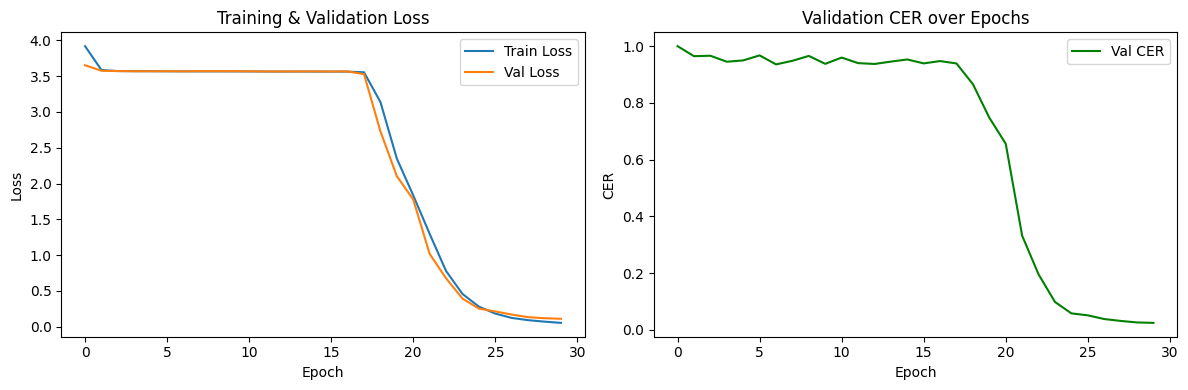

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()

ax2.plot(history['val_cer'], label='Val CER', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('CER')
ax2.set_title('Validation CER over Epochs')
ax2.legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/training_curves.png", dpi=150)
plt.show()

In [36]:
# Run on full validation set and collect errors
model.eval()
error_cases = []
char_errors = {}

with torch.no_grad():
    for imgs, labels, label_strs in val_loader:
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda'):
            outputs = model(imgs)
        preds = decode_predictions(outputs)

        for pred, target in zip(preds, label_strs):
            if pred != target:
                error_cases.append((pred, target))
            # Per-character analysis
            for i, (p, t) in enumerate(zip(pred, target)):
                if p != t:
                    key = t  # true character
                    if key not in char_errors:
                        char_errors[key] = []
                    char_errors[key].append(p)  # what it predicted instead

print(f"Total errors: {len(error_cases)} / {len(val_dataset)}")
print(f"Accuracy: {1 - len(error_cases)/len(val_dataset):.4f}")
print(f"\nTop confused characters:")
for char, mistakes in sorted(char_errors.items(), key=lambda x: len(x[1]), reverse=True)[:10]:
    print(f"  '{char}' confused as: {dict(pd.Series(mistakes).value_counts().head(3).items())}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Total errors: 283 / 2000
Accuracy: 0.8585

Top confused characters:
  '5' confused as: {'8': 11, '6': 6, '9': 2}
  'C' confused as: {'G': 17, 'Q': 6, 'J': 1}
  '6' confused as: {'8': 17, 'G': 2, '5': 2}
  'F' confused as: {'P': 11, 'E': 6, 'S': 2}
  '8' confused as: {'6': 6, 'G': 2, 'Q': 2}
  'Z' confused as: {'2': 9, 'D': 2, 'K': 1}
  'G' confused as: {'C': 5, '8': 2, 'Q': 2}
  'P' confused as: {'F': 3, 'T': 2, 'R': 2}
  '3' confused as: {'9': 8, '5': 2, 'D': 2}
  'B' confused as: {'8': 5, 'D': 3, 'M': 2}


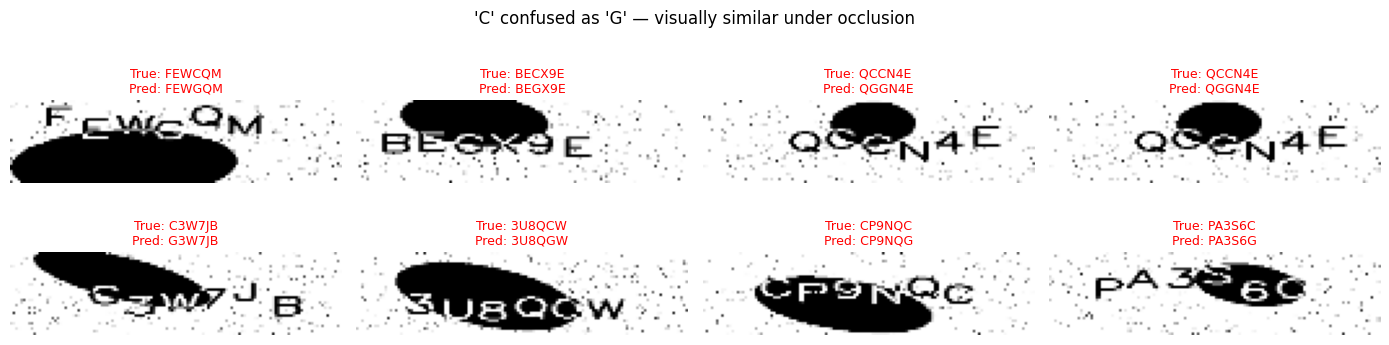

In [37]:
# Visualize worst confused pairs
import matplotlib.pyplot as plt
import random

# Find error cases for C→G confusion (worst one)
target_char = 'C'
confused_as = 'G'

confused_samples = []
model.eval()

with torch.no_grad():
    for imgs, labels, label_strs in val_loader:
        imgs_gpu = imgs.to(device)
        with torch.amp.autocast('cuda'):
            outputs = model(imgs_gpu)
        preds = decode_predictions(outputs)

        for img, pred, target in zip(imgs, preds, label_strs):
            if len(pred) == len(target):
                for i, (p, t) in enumerate(zip(pred, target)):
                    if t == target_char and p == confused_as:
                        confused_samples.append((img, pred, target))
            if len(confused_samples) >= 8:
                break
        if len(confused_samples) >= 8:
            break

# Plot them
fig, axes = plt.subplots(2, 4, figsize=(14, 4))
fig.suptitle(f"'{target_char}' confused as '{confused_as}' — visually similar under occlusion",
             fontsize=12)
for i, ax in enumerate(axes.flat):
    if i < len(confused_samples):
        img, pred, target = confused_samples[i]
        ax.imshow(img.squeeze().numpy(), cmap='gray')
        ax.set_title(f"True: {target}\nPred: {pred}", fontsize=9, color='red')
    ax.axis('off')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_visualization.png", dpi=150)
plt.show()